# Hospital Patient & Healthcare Analytics

### Admissions, Cost, Readmission Risk & Patient Satisfaction Analysis

**Objective:**  
Analyze two years of hospital admission data to evaluate departmental performance, patient demographics, treatment costs, length of stay, patient satisfaction, and 30-day readmission patterns. The project also develops an interpretable readmission risk model and additional risk-segmentation techniques to support data-driven discharge planning and hospital operations.

**Dataset:**  
`data/raw/hospital_admissions_data.csv` — 13,266 hospital admission records with 14 original features covering patient demographics, department, diagnosis, insurance type, admission type, length of stay, billing amount, discharge status, 30-day readmission, and patient satisfaction.

**Tools & Technologies:**  
- **Python:** pandas, NumPy, Matplotlib, seaborn for data cleaning, feature engineering, exploratory data analysis, statistical analysis, and visualization  
- **Machine Learning:** scikit-learn with Logistic Regression for 30-day readmission risk prediction and ROC-AUC evaluation  
- **SQL / MySQL:** patient, department, financial, and readmission analysis using structured business queries  
- **SQLAlchemy & PyMySQL:** Python-to-MySQL database connectivity  
- **Power BI:** interactive healthcare dashboards, KPI reporting, department analysis, financial insights, and patient-risk visualization  

**Additional Analytics:**  
IQR-based billing outlier detection, department performance analysis, patient risk segmentation, correlation analysis, and engineered features such as age groups, stay categories, billing categories, and readmission status.

In [47]:
import pandas as pd

df = pd.read_csv("../data/raw/hospital_admissions_data.csv")
df.head()

,admission_id,patient_id,admission_date,department,diagnosis,age,gender,insurance_type,admission_type,length_of_stay_days,billing_amount,discharge_status,is_readmission_30d,patient_satisfaction
0,ADM306377,PT24506,2024-01-01,General Medicine,Diabetes Mellitus,69,Male,Corporate Insurance,Referral,5,35516.43,Recovered,False,5.0
1,ADM304754,PT23379,2024-01-01,General Medicine,Viral Fever,58,Female,Self-Pay,Emergency,5,37382.32,Recovered,False,4.0
2,ADM311557,PT28133,2024-01-01,Gynecology,C-Section,34,Male,Self-Pay,Elective,5,41269.39,Recovered,False,2.0
3,ADM309559,PT26701,2024-01-01,Cardiology,Hypertension,72,Male,Self-Pay,Referral,2,64657.99,Recovered,False,3.0
4,ADM300616,PT20457,2024-01-01,Emergency,Acute Abdomen,60,Female,Corporate Insurance,Elective,4,27881.82,Recovered,False,5.0


In [48]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Shape: (13266, 14)

Columns:
['admission_id', 'patient_id', 'admission_date', 'department', 'diagnosis', 'age', 'gender', 'insurance_type', 'admission_type', 'length_of_stay_days', 'billing_amount', 'discharge_status', 'is_readmission_30d', 'patient_satisfaction']

Missing Values:
admission_id              0
patient_id                0
admission_date            0
department                0
diagnosis                 0
age                       0
gender                    0
insurance_type            0
admission_type            0
length_of_stay_days       0
billing_amount            0
discharge_status          0
is_readmission_30d        0
patient_satisfaction    255
dtype: int64

Duplicates: 0

Data Types:
admission_id             object
patient_id               object
admission_date           object
department               object
diagnosis                object
age                       int64
gender                   object
insurance_type           object
admission_type           obje

In [49]:
df["admission_date"] = pd.to_datetime(df["admission_date"])

print(df["admission_date"].min())
print(df["admission_date"].max())

2024-01-01 00:00:00
2025-12-31 00:00:00


In [50]:
satisfaction_median = df["patient_satisfaction"].median()

df["patient_satisfaction"] = df["patient_satisfaction"].fillna(
    satisfaction_median
)

print("Missing values remaining:")
print(df.isnull().sum())

Missing values remaining:
admission_id            0
patient_id              0
admission_date          0
department              0
diagnosis               0
age                     0
gender                  0
insurance_type          0
admission_type          0
length_of_stay_days     0
billing_amount          0
discharge_status        0
is_readmission_30d      0
patient_satisfaction    0
dtype: int64


In [51]:
# Age Group
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 35, 50, 65, 120],
    labels=["0-18", "19-35", "36-50", "51-65", "65+"],
    include_lowest=True
)

# Length of Stay Category
df["stay_category"] = pd.cut(
    df["length_of_stay_days"],
    bins=[-1, 3, 7, float("inf")],
    labels=["Short Stay", "Medium Stay", "Long Stay"]
)

# Date features
df["admission_year"] = df["admission_date"].dt.year
df["admission_month"] = df["admission_date"].dt.month_name()
df["admission_month_no"] = df["admission_date"].dt.month
df["admission_quarter"] = df["admission_date"].dt.quarter

# High Billing Flag
billing_threshold = df["billing_amount"].quantile(0.75)

df["billing_category"] = df["billing_amount"].apply(
    lambda x: "High Cost" if x >= billing_threshold else "Normal Cost"
)

print(df.head())

  admission_id patient_id admission_date        department          diagnosis  \
0    ADM306377    PT24506     2024-01-01  General Medicine  Diabetes Mellitus   
1    ADM304754    PT23379     2024-01-01  General Medicine        Viral Fever   
2    ADM311557    PT28133     2024-01-01        Gynecology          C-Section   
3    ADM309559    PT26701     2024-01-01        Cardiology       Hypertension   
4    ADM300616    PT20457     2024-01-01         Emergency      Acute Abdomen   

   age  gender       insurance_type admission_type  length_of_stay_days  ...  \
0   69    Male  Corporate Insurance       Referral                    5  ...   
1   58  Female             Self-Pay      Emergency                    5  ...   
2   34    Male             Self-Pay       Elective                    5  ...   
3   72    Male             Self-Pay       Referral                    2  ...   
4   60  Female  Corporate Insurance       Elective                    4  ...   

   discharge_status is_readmissi

In [52]:
df["readmission_status"] = df["is_readmission_30d"].map(
    {True: "Readmitted", False: "Not Readmitted"}
)

In [53]:
print("Final Shape:", df.shape)

print("\nFinal Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

Final Shape: (13266, 22)

Final Columns:
['admission_id', 'patient_id', 'admission_date', 'department', 'diagnosis', 'age', 'gender', 'insurance_type', 'admission_type', 'length_of_stay_days', 'billing_amount', 'discharge_status', 'is_readmission_30d', 'patient_satisfaction', 'age_group', 'stay_category', 'admission_year', 'admission_month', 'admission_month_no', 'admission_quarter', 'billing_category', 'readmission_status']

Missing Values:
admission_id            0
patient_id              0
admission_date          0
department              0
diagnosis               0
age                     0
gender                  0
insurance_type          0
admission_type          0
length_of_stay_days     0
billing_amount          0
discharge_status        0
is_readmission_30d      0
patient_satisfaction    0
age_group               0
stay_category           0
admission_year          0
admission_month         0
admission_month_no      0
admission_quarter       0
billing_category        0
readmiss

In [54]:
output_path = "../data/processed/hospital_admissions_cleaned.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully:")
print(output_path)

Cleaned dataset saved successfully:
../data/processed/hospital_admissions_cleaned.csv


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv(
    "../data/processed/hospital_admissions_cleaned.csv",
    parse_dates=["admission_date"]
)

df["is_readmission_30d"] = df["is_readmission_30d"].astype(bool)

df.shape

(13266, 22)

## 1. Setup & Data Loading

In [57]:
from getpass import getpass
from sqlalchemy import create_engine, URL

mysql_password = getpass("Enter your MySQL password: ")

connection_url = URL.create(
    "mysql+pymysql",
    username="root",
    password=mysql_password,
    host="localhost",
    port=3306,
    database="Hospital_analytics"
)

engine = create_engine(connection_url)

Enter your MySQL password:  ········


In [58]:
engine = create_engine(connection_url)

In [59]:
with engine.connect() as conn:
    print("MySQL connection successful!")

MySQL connection successful!


In [60]:
with engine.connect() as conn:
    result = conn.exec_driver_sql("SHOW TABLES")
    for row in result:
        print(row)

('admissions',)


In [61]:
df = pd.read_sql("SELECT * FROM admissions", engine)

In [62]:
df.head()

,admission_id,patient_id,admission_date,department,diagnosis,age,gender,insurance_type,admission_type,length_of_stay_days,...,is_readmission_30d,patient_satisfaction,age_group,stay_category,admission_year,admission_month,admission_month_no,admission_quarter,billing_category,readmission_status
0,ADM306377,PT24506,2024-01-01,General Medicine,Diabetes Mellitus,69,Male,Corporate Insurance,Referral,5,...,False,5.0,65+,Medium Stay,2024,January,1,1,Normal Cost,Not Readmitted
1,ADM304754,PT23379,2024-01-01,General Medicine,Viral Fever,58,Female,Self-Pay,Emergency,5,...,False,4.0,51-65,Medium Stay,2024,January,1,1,Normal Cost,Not Readmitted
2,ADM311557,PT28133,2024-01-01,Gynecology,C-Section,34,Male,Self-Pay,Elective,5,...,False,2.0,19-35,Medium Stay,2024,January,1,1,Normal Cost,Not Readmitted
3,ADM309559,PT26701,2024-01-01,Cardiology,Hypertension,72,Male,Self-Pay,Referral,2,...,False,3.0,65+,Short Stay,2024,January,1,1,Normal Cost,Not Readmitted
4,ADM300616,PT20457,2024-01-01,Emergency,Acute Abdomen,60,Female,Corporate Insurance,Elective,4,...,False,5.0,51-65,Medium Stay,2024,January,1,1,Normal Cost,Not Readmitted


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13266 entries, 0 to 13265
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   admission_id          13266 non-null  object 
 1   patient_id            13266 non-null  object 
 2   admission_date        13266 non-null  object 
 3   department            13266 non-null  object 
 4   diagnosis             13266 non-null  object 
 5   age                   13266 non-null  int64  
 6   gender                13266 non-null  object 
 7   insurance_type        13266 non-null  object 
 8   admission_type        13266 non-null  object 
 9   length_of_stay_days   13266 non-null  int64  
 10  billing_amount        13266 non-null  float64
 11  discharge_status      13266 non-null  object 
 12  is_readmission_30d    13266 non-null  object 
 13  patient_satisfaction  13266 non-null  float64
 14  age_group             13266 non-null  object 
 15  stay_category      

## 2. Data Quality Checks

In [64]:
df.isnull().sum()

admission_id            0
patient_id              0
admission_date          0
department              0
diagnosis               0
age                     0
gender                  0
insurance_type          0
admission_type          0
length_of_stay_days     0
billing_amount          0
discharge_status        0
is_readmission_30d      0
patient_satisfaction    0
age_group               0
stay_category           0
admission_year          0
admission_month         0
admission_month_no      0
admission_quarter       0
billing_category        0
readmission_status      0
dtype: int64

In [65]:
# patient_satisfaction is expected to be null only for Deceased patients
df.loc[df['discharge_status'] == 'Deceased', 'patient_satisfaction'].isnull().mean()


np.float64(0.0)

In [66]:
df.loc[
    df['patient_satisfaction'].isnull(),
    'discharge_status'
].value_counts()

Series([], Name: count, dtype: int64)

In [67]:
df[['age','length_of_stay_days','billing_amount']].describe()

,age,length_of_stay_days,billing_amount
count,13266.000000,13266.000000,13266.000000
mean,41.799261,4.572441,85245.620938
std,22.010015,2.840646,58160.966625
min,0.000000,1.000000,16989.790000
25%,26.000000,2.000000,40973.275000
50%,42.000000,4.000000,64465.910000
75%,57.000000,6.000000,117875.335000
max,95.000000,19.000000,368652.030000


## 3. Hospital KPI Overview

In [69]:
df["is_readmission_30d"] = (
    df["is_readmission_30d"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "true": 1,
        "false": 0,
        "1": 1,
        "0": 0
    })
)

df["billing_amount"] = pd.to_numeric(df["billing_amount"], errors="coerce")
df["length_of_stay_days"] = pd.to_numeric(df["length_of_stay_days"], errors="coerce")
df["patient_satisfaction"] = pd.to_numeric(df["patient_satisfaction"], errors="coerce")

In [94]:
print(f"Total Admissions:      {len(df):,}")
print(f"Unique Patients:       {df['patient_id'].nunique():,}")
print(f"Total Billing Amount:   ₹{df['billing_amount'].sum():,.2f}")
print(f"Avg Length of Stay:     {df['length_of_stay_days'].mean():.2f} days")
print(f"Readmission Rate:       {df['is_readmission_30d'].mean() * 100:.2f}%")
print(f"Avg Satisfaction:       {df['patient_satisfaction'].mean():.2f} / 5")

Total Admissions:      13,266
Unique Patients:       8,436
Total Billing Amount:   ₹1,130,868,407.37
Avg Length of Stay:     4.57 days
Readmission Rate:       10.60%
Avg Satisfaction:       3.76 / 5


## 4. Monthly Admissions & Revenue Trend

In [71]:
print(df["admission_date"].dtype)
print(df["admission_date"].head())

object
0    2024-01-01
1    2024-01-01
2    2024-01-01
3    2024-01-01
4    2024-01-01
Name: admission_date, dtype: object


In [72]:
df["admission_date"] = pd.to_datetime(
    df["admission_date"],
    errors="coerce"
)

print(df["admission_date"].dtype)

datetime64[ns]


In [73]:
monthly = (
    df.set_index("admission_date")
      .resample("MS")
      .agg(
          admissions=("admission_id", "count"),
          revenue=("billing_amount", "sum")
      )
)

print(monthly.head())

                admissions      revenue
admission_date                         
2024-01-01             618  54007672.04
2024-02-01             667  55358369.80
2024-03-01             520  43921261.90
2024-04-01             532  46242976.75
2024-05-01             478  40645910.53


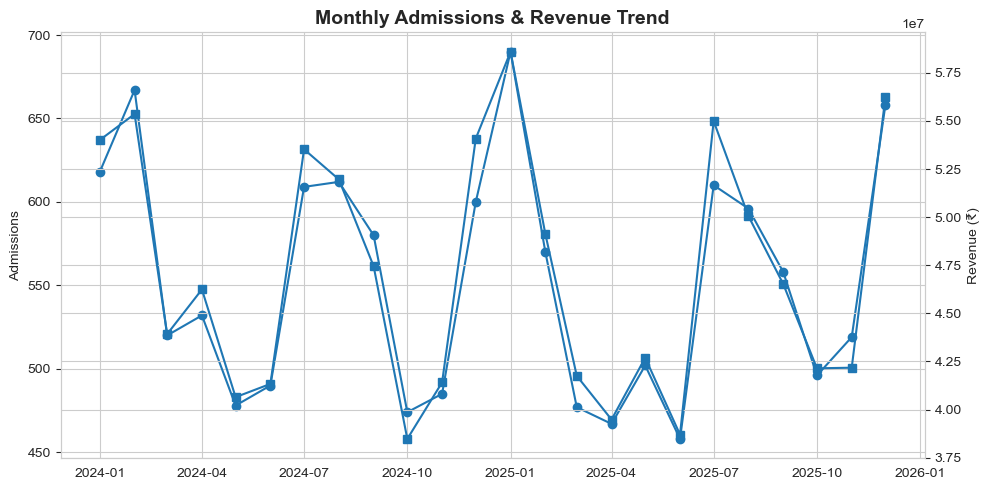

In [74]:
fig, ax1 = plt.subplots()

ax1.plot(
    monthly.index,
    monthly["admissions"],
    marker="o",
    label="Admissions"
)

ax1.set_ylabel("Admissions")

ax2 = ax1.twinx()

ax2.plot(
    monthly.index,
    monthly["revenue"],
    marker="s",
    label="Revenue"
)

ax2.set_ylabel("Revenue (₹)")

ax1.set_title(
    "Monthly Admissions & Revenue Trend",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Insight:** Admissions rise in winter months (Dec-Feb, respiratory/cardiac cases) and monsoon months (Jul-Sep, infections), consistent with seasonal disease patterns.

## 5. Department Performance

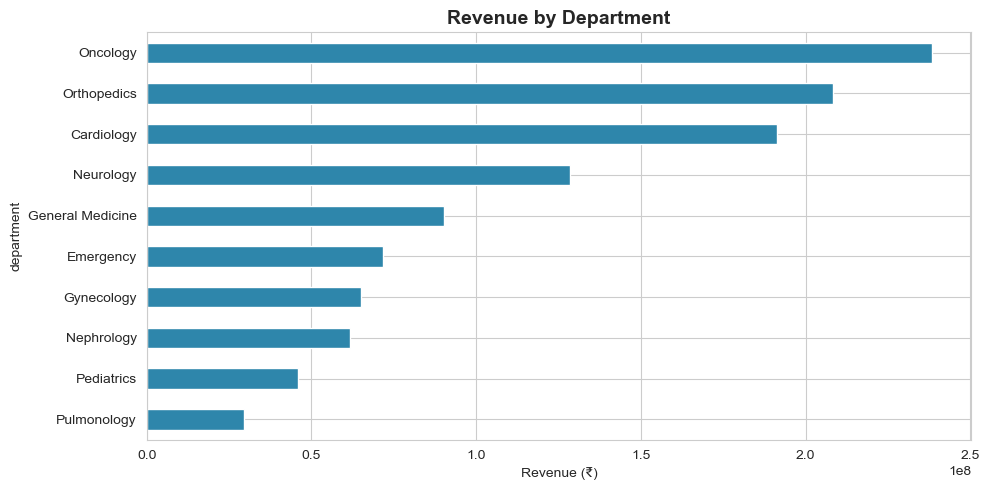

In [75]:
dept = df.groupby("department").agg(
    admissions=("admission_id","count"), revenue=("billing_amount","sum")
).sort_values("revenue", ascending=False)

fig, ax = plt.subplots()
dept["revenue"].plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title("Revenue by Department", fontsize=14, fontweight='bold')
ax.set_xlabel("Revenue (₹)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 6. Readmission Rate by Department

In [76]:
df["is_readmission_30d"] = (
    df["is_readmission_30d"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "true": 1,
        "false": 0,
        "1": 1,
        "0": 0
    })
)

print(df["is_readmission_30d"].value_counts(dropna=False))
print(df["is_readmission_30d"].dtype)

is_readmission_30d
0    11860
1     1406
Name: count, dtype: int64
int64


In [77]:
readmit_dept = (
    df.groupby("department")["is_readmission_30d"]
    .mean()
    .sort_values(ascending=False) * 100
)

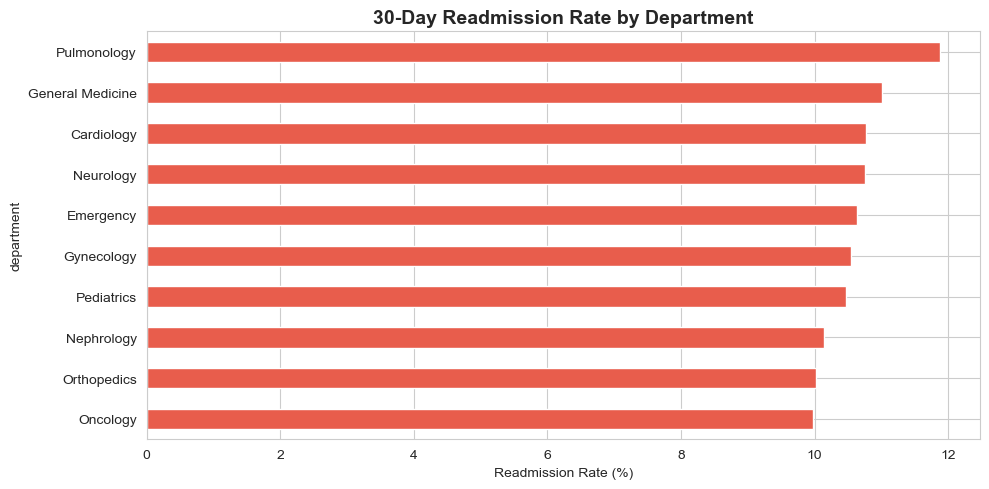

In [78]:
readmit_dept = df.groupby("department")["is_readmission_30d"].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots()
readmit_dept.plot(kind='barh', ax=ax, color='#E85D4C')
ax.set_title("30-Day Readmission Rate by Department", fontsize=14, fontweight='bold')
ax.set_xlabel("Readmission Rate (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 7. Patient Demographics

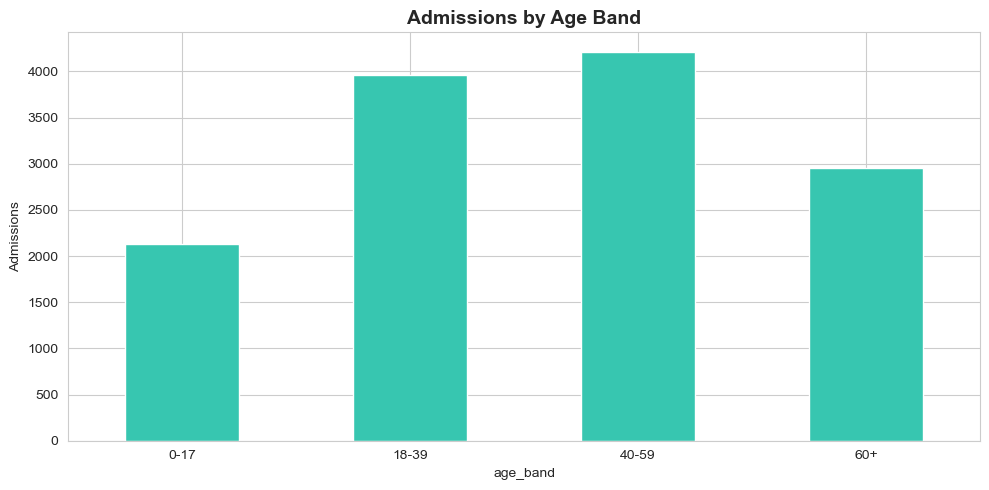

In [79]:
bins = [0, 18, 40, 60, 100]
labels = ['0-17', '18-39', '40-59', '60+']
df['age_band'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
age_dist = df['age_band'].value_counts().reindex(labels)

fig, ax = plt.subplots()
age_dist.plot(kind='bar', ax=ax, color='#37C6B0')
ax.set_title("Admissions by Age Band", fontsize=14, fontweight='bold')
ax.set_ylabel("Admissions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Revenue by Insurance Type

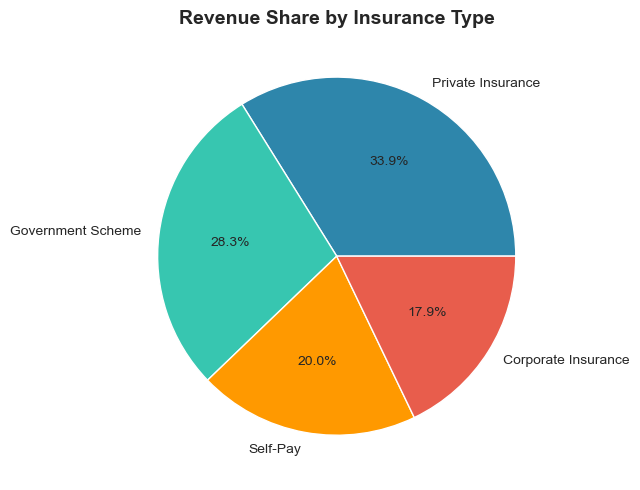

In [80]:
ins = df.groupby("insurance_type")["billing_amount"].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
ax.pie(ins.values, labels=ins.index, autopct='%1.1f%%', colors=['#2E86AB','#37C6B0','#FF9900','#E85D4C'])
ax.set_title("Revenue Share by Insurance Type", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Length of Stay vs Patient Satisfaction

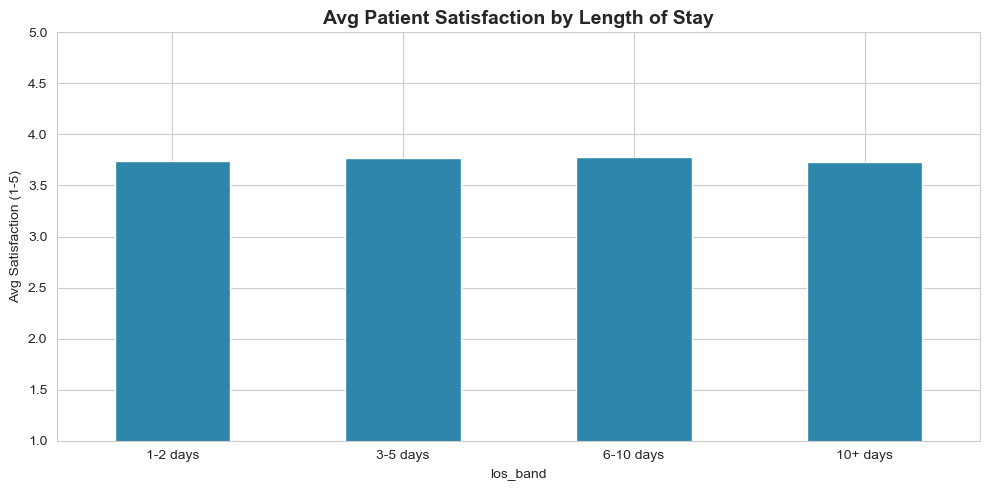

In [81]:
bins2 = [0, 2, 5, 10, 100]
labels2 = ['1-2 days', '3-5 days', '6-10 days', '10+ days']
df['los_band'] = pd.cut(df['length_of_stay_days'], bins=bins2, labels=labels2, right=True)
sat_by_los = df.groupby('los_band', observed=True)['patient_satisfaction'].mean()

fig, ax = plt.subplots()
sat_by_los.plot(kind='bar', ax=ax, color='#2E86AB')
ax.set_title("Avg Patient Satisfaction by Length of Stay", fontsize=14, fontweight='bold')
ax.set_ylabel("Avg Satisfaction (1-5)")
ax.set_ylim(1,5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight:** Satisfaction drops noticeably for stays beyond 10 days, likely reflecting complication-driven extended admissions rather than the stay length itself.

## 10. Readmission Risk Model (Logistic Regression)

Hospitals are increasingly evaluated (and reimbursed) based on 30-day readmission rates. Here we build a simple, interpretable model to flag high-risk patients **at the time of discharge**, using features available at that point: department, diagnosis-adjacent department, insurance type, admission type, age, length of stay, and billing amount.

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

model_df = df.copy()
model_df = pd.get_dummies(model_df, columns=["department", "insurance_type", "admission_type", "gender"], drop_first=True)

feature_cols = [c for c in model_df.columns if c.startswith(("department_","insurance_type_","admission_type_","gender_"))]
feature_cols += ["age", "length_of_stay_days", "billing_amount"]

X = model_df[feature_cols].fillna(0)
y = model_df["is_readmission_30d"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_s, y_train)

y_prob = clf.predict_proba(X_test_s)[:, 1]
y_pred = clf.predict(X_test_s)

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.3f}")
print(classification_report(y_test, y_pred, target_names=["No Readmission", "Readmission"]))


ROC-AUC: 0.812
                precision    recall  f1-score   support

No Readmission       0.99      0.59      0.74      2965
   Readmission       0.21      0.93      0.34       352

      accuracy                           0.62      3317
     macro avg       0.60      0.76      0.54      3317
  weighted avg       0.90      0.62      0.69      3317



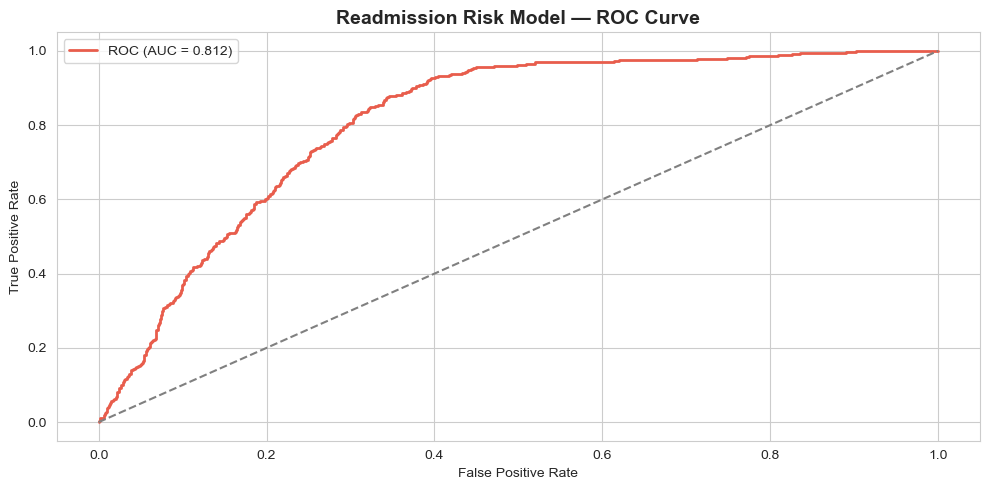

In [83]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, color='#E85D4C', linewidth=2, label=f'ROC (AUC = {auc:.3f})')
ax.plot([0,1],[0,1], linestyle='--', color='gray')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Readmission Risk Model — ROC Curve", fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### Feature Importance (What Drives Readmission Risk?)

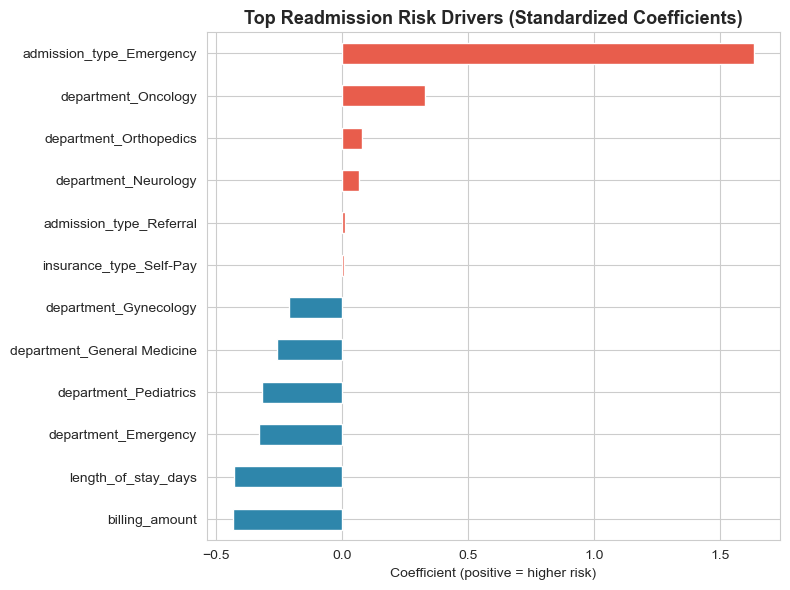

In [84]:
coefs = pd.Series(clf.coef_[0], index=feature_cols).sort_values()
top_coefs = pd.concat([coefs.head(6), coefs.tail(6)])

fig, ax = plt.subplots(figsize=(8,6))
colors = ['#E85D4C' if v > 0 else '#2E86AB' for v in top_coefs.values]
top_coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title("Top Readmission Risk Drivers (Standardized Coefficients)", fontsize=13, fontweight='bold')
ax.set_xlabel("Coefficient (positive = higher risk)")
plt.tight_layout()
plt.show()


## 11. Advanced Analytics & Patient Risk Segmentation

To extend the analysis beyond descriptive reporting and predictive modeling, additional statistical and risk-based analysis was performed to identify billing outliers, compare departmental performance, and segment potentially high-risk patient admissions.

### 11.1 Billing Outlier Detection using IQR

In [85]:
# Billing Outlier Detection using the Interquartile Range (IQR)

Q1 = df["billing_amount"].quantile(0.25)
Q3 = df["billing_amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["billing_outlier"] = (
    (df["billing_amount"] < lower_bound) |
    (df["billing_amount"] > upper_bound)
)

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Billing Outliers: {df['billing_outlier'].sum()}")
print(f"Outlier Percentage: {df['billing_outlier'].mean() * 100:.2f}%")

Q1: 40973.27
Q3: 117875.33
IQR: 76902.06
Lower Bound: -74379.82
Upper Bound: 233228.42
Billing Outliers: 449
Outlier Percentage: 3.38%


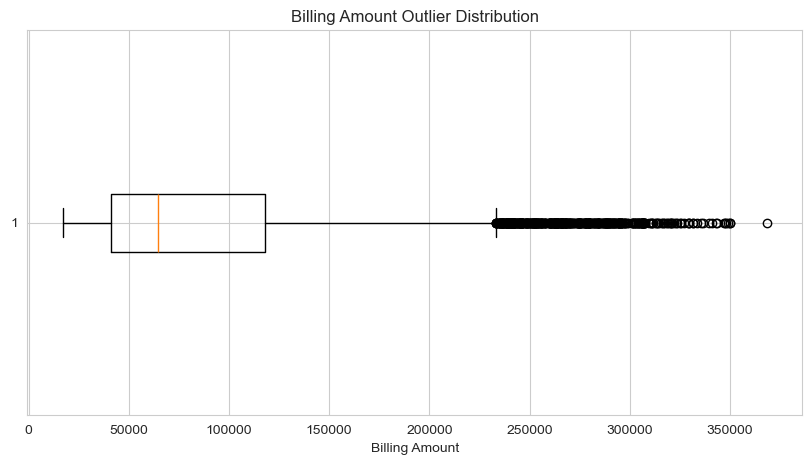

In [86]:
plt.figure(figsize=(10, 5))

plt.boxplot(df["billing_amount"].dropna(), vert=False)

plt.title("Billing Amount Outlier Distribution")
plt.xlabel("Billing Amount")

plt.show()

### 11.2 Department Performance & Risk Analysis

In [87]:
department_analysis = (
    df.groupby("department")
    .agg(
        total_admissions=("admission_id", "count"),
        average_billing=("billing_amount", "mean"),
        average_length_of_stay=("length_of_stay_days", "mean"),
        readmission_rate=("is_readmission_30d", "mean"),
        average_patient_satisfaction=("patient_satisfaction", "mean")
    )
    .reset_index()
)

department_analysis["readmission_rate"] = (
    department_analysis["readmission_rate"] * 100
)

department_analysis = department_analysis.round(2)

department_analysis

,department,total_admissions,average_billing,average_length_of_stay,readmission_rate,average_patient_satisfaction
0,Cardiology,1708,112017.92,5.13,10.77,3.79
1,Emergency,1880,38116.48,2.21,10.64,3.74
2,General Medicine,2089,43173.90,3.21,11.01,3.76
3,Gynecology,1157,56324.03,3.27,10.54,3.79
4,Nephrology,690,89385.53,5.32,10.14,3.74
5,Neurology,1199,107288.33,6.26,10.76,3.77
6,Oncology,1082,220339.69,8.54,9.98,3.71
7,Orthopedics,1586,131406.70,6.42,10.03,3.80
8,Pediatrics,1328,34509.89,3.19,10.47,3.76
9,Pulmonology,547,54046.09,4.40,11.88,3.77


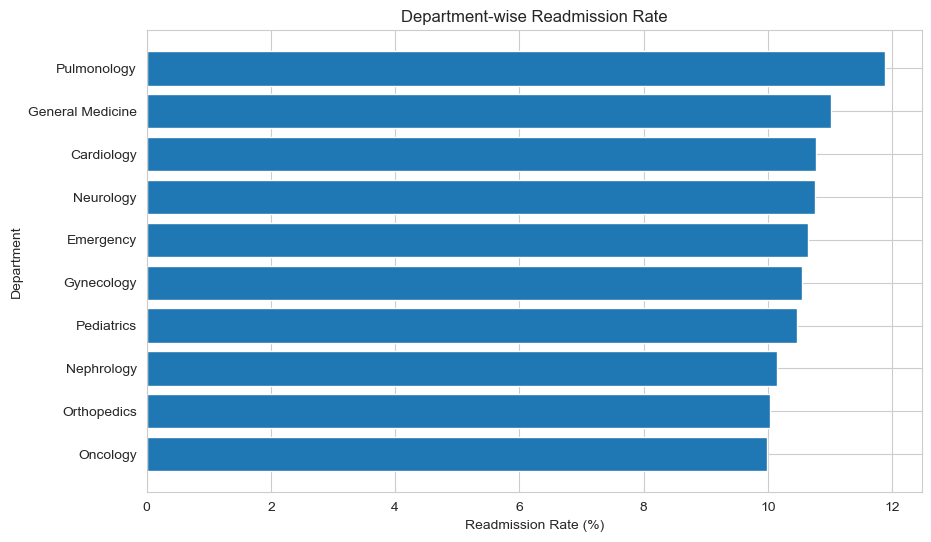

In [88]:
department_risk = department_analysis.sort_values(
    "readmission_rate",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    department_risk["department"],
    department_risk["readmission_rate"]
)

plt.title("Department-wise Readmission Rate")
plt.xlabel("Readmission Rate (%)")
plt.ylabel("Department")

plt.show()

### 11.3 High-Risk Patient Segmentation

In [89]:
billing_threshold = df["billing_amount"].quantile(0.75)
stay_threshold = df["length_of_stay_days"].quantile(0.75)

df["patient_risk"] = np.where(
    (
        (df["billing_amount"] >= billing_threshold) &
        (df["length_of_stay_days"] >= stay_threshold)
    )
    |
    (df["is_readmission_30d"] == 1),
    "High Risk",
    "Normal Risk"
)

risk_summary = df["patient_risk"].value_counts()

risk_summary

patient_risk
Normal Risk    9681
High Risk      3585
Name: count, dtype: int64

In [90]:
risk_percentage = (
    df["patient_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

risk_percentage

patient_risk
Normal Risk    72.98
High Risk      27.02
Name: proportion, dtype: float64

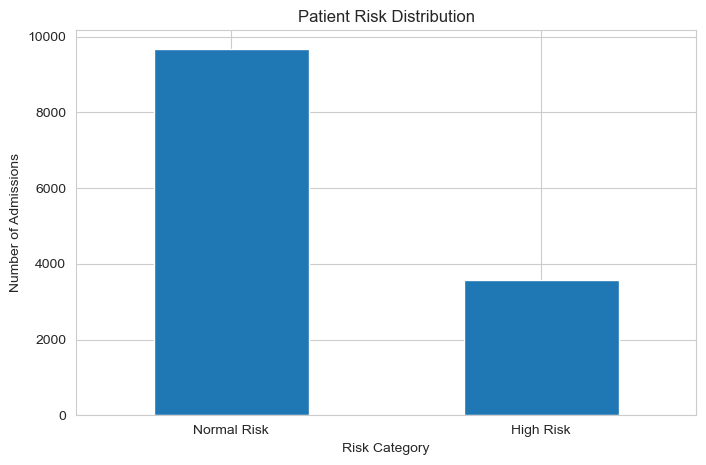

In [91]:
plt.figure(figsize=(8, 5))

df["patient_risk"].value_counts().plot(
    kind="bar"
)

plt.title("Patient Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=0)

plt.show()

### 11.4 Correlation Analysis of Clinical and Financial Variables

In [92]:
correlation_columns = [
    "age",
    "length_of_stay_days",
    "billing_amount",
    "patient_satisfaction",
    "is_readmission_30d"
]

correlation_data = df[correlation_columns].copy()

correlation_matrix = correlation_data.corr()

correlation_matrix.round(2)

,age,length_of_stay_days,billing_amount,patient_satisfaction,is_readmission_30d
age,1.00,0.13,0.21,0.02,0.00
length_of_stay_days,0.13,1.00,0.67,0.01,-0.10
billing_amount,0.21,0.67,1.00,-0.00,-0.04
patient_satisfaction,0.02,0.01,-0.00,1.00,-0.14
is_readmission_30d,0.00,-0.10,-0.04,-0.14,1.00


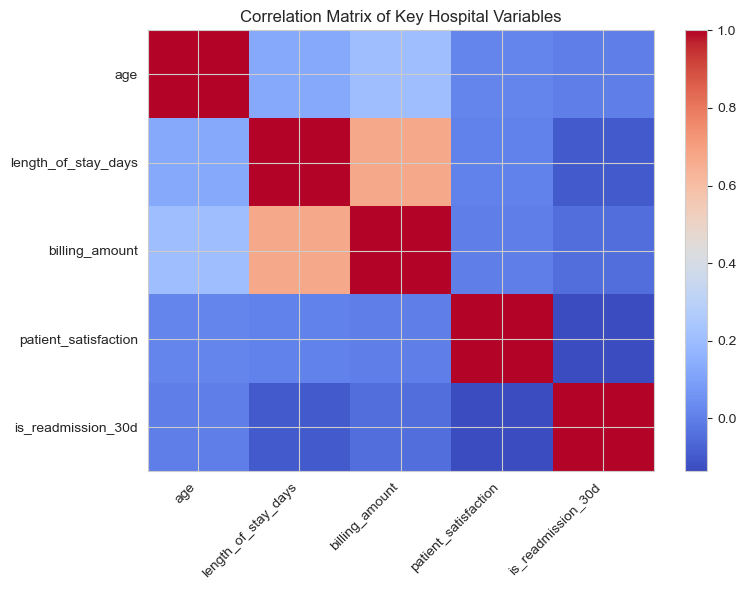

In [93]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title("Correlation Matrix of Key Hospital Variables")

plt.tight_layout()
plt.show()

In [96]:
df.to_sql(
    "admissions_updated",
    con=engine,
    if_exists="replace",
    index=False
)

print("Updated table uploaded to MySQL successfully.")

Updated table uploaded to MySQL successfully.


## 12. Key Findings & Recommendations

### Findings

1. Admissions and revenue show clear seasonal variation, with noticeable peaks during winter and monsoon periods. These patterns indicate predictable changes in patient demand across the year.

2. Department-level analysis shows that **General Medicine has the highest admission volume with 2,089 admissions**, followed by Emergency with 1,880 admissions. This highlights the departments carrying the greatest patient load.

3. **Pulmonology records the highest 30-day readmission rate at 11.88%**, followed by General Medicine at 11.01%. These departments may require closer review of discharge planning and post-discharge care.

4. **Oncology has the highest average billing amount at 220,339.69 per admission** and also the longest average length of stay at **8.54 days**, indicating a resource-intensive patient segment.

5. Orthopedics records the highest average patient satisfaction score at approximately **3.80**, while Oncology shows a comparatively lower average satisfaction score of **3.71**.

6. The overall 30-day readmission rate is approximately **10.6%**, with meaningful variation across departments. This indicates that readmission risk is not evenly distributed across hospital services.

7. The Logistic Regression readmission risk model achieves an **ROC-AUC of approximately 0.81**, demonstrating useful ability to distinguish higher-risk from lower-risk admissions using routinely available hospital data.

8. IQR-based billing analysis identified **449 billing outliers**, representing **3.38% of all admissions**. These cases form a relatively small but important group of unusually high or low billing observations that may require additional financial review.

9. Patient risk segmentation classified **3,585 admissions (27.02%) as High Risk** and **9,681 admissions (72.98%) as Normal Risk**. This shows that more than one-quarter of admissions fall into a higher-risk segment requiring closer monitoring.

10. Correlation analysis shows the strongest relationship between **length of stay and billing amount (r = 0.67)**, indicating that longer hospital stays are generally associated with higher treatment costs.

11. Patient satisfaction has a weak negative correlation with 30-day readmission **(r = -0.14)**, while age and billing amount show only weak direct relationships with readmission risk.

12. The combined department analysis, billing outlier detection, correlation analysis, predictive modeling, and patient risk segmentation provide a broader view of hospital operational efficiency, financial performance, patient experience, and readmission risk.

### Recommendations

- Prioritize **Pulmonology and General Medicine** for detailed review of discharge protocols, follow-up procedures, and care-transition practices because of their comparatively higher readmission rates.

- Use the readmission risk model during discharge planning to flag higher-risk patients for additional follow-up, care-coordinator review, or early post-discharge contact.

- Closely monitor the **3,585 High Risk admissions** identified through risk segmentation and prioritize patients with readmission indicators, extended hospital stays, or high billing amounts.

- Investigate the **449 billing outliers** separately to identify the operational or clinical factors responsible for unusually high treatment costs.

- Review Oncology resource utilization because it combines the highest average billing amount with the longest average length of stay.

- Monitor long-stay patients more closely, as extended hospitalization is strongly associated with higher billing and may also affect patient experience.

- Use department-level performance metrics together rather than relying only on admission volume. Readmission rate, billing, length of stay, and patient satisfaction should be evaluated jointly.

- Use seasonal admission trends for proactive workforce planning, bed allocation, inventory management, and hospital capacity planning.

- Track high-risk patients and readmission outcomes over time to evaluate whether discharge interventions and follow-up programs are reducing avoidable readmissions.

- Continue monitoring patient satisfaction alongside operational metrics so that cost control and efficiency improvements do not negatively affect patient experience.